# 03 — 埋め込みは人手のルールに並ぶか

[02_baseline.ipynb](02_baseline.ipynb) の続き。前回わかったことは2つだった。

1. 一番効いたのは **グレード名**（−3.91万円）。カーセンサーのタイトル文から
   **正規表現**（文字列のパターンを指定して抜き出す記法）で取り出した列
2. 装備テキストを TF-IDF で入れても **−0.67万円**しか出ない

ここから出てくるのが、`unfold` 機能A（Feature）の成否を分ける問いである。

> グレード名は今回**人間が正規表現を書いて**取り出した。
> **機械に自動でやらせても同じ情報が取れるのか？**

取れるなら、機能A の前提（非構造テキストから人手のルールなしに特徴量を作れる）が成り立つ。
取れないなら、仕様書の設計を考え直す必要がある。

このノートブックでは **埋め込み（embedding）** を使ってこれを確かめる。立てる問いは2つ。

| | 問い | 比べる相手 |
|---|---|---|
| **D1** | 埋め込みは TF-IDF に勝つか | C2（文字TF-IDF）= MAE 12.21 |
| **D2** | **正規表現なしでグレード情報を取れるか** ★本命 | Ab1（正規表現でグレード名抽出）= MAE 13.60 |

---

## 0. セットアップ

### なぜ環境を分ける必要があったのか

埋め込みを計算するには **PyTorch**（深層学習のライブラリ）が要る。ところが：

- このマシンは **Intel Mac**。PyTorch は **2.2.2 が上限**
  （それ以降は Apple Silicon 向けしかビルドされていない）
- torch 2.2.2 は **numpy 1.x** の時代のもので、主環境の **numpy 2.5.2 と非互換**
- 主環境に入れると pandas / LightGBM ごと壊れる

そこで **`.venv-embed`** という隔離環境を別に作り、そこで埋め込みだけ計算して
**parquet ファイルに保存**し、主環境ではその数値を読むだけにした。
torch のオブジェクトは主環境に一切渡らない。

```
.venv-embed/   numpy 1.26.4 + torch 2.2.2 + sentence-transformers 2.7.0
               ↓  parquet（ただの数値の表）で受け渡し
.venv/         numpy 2.5.2 ← 無傷。このノートブックはこちらで動く
```

### 事前に実行しておくこと

```bash
bash scripts/setup_embed_env.sh                # 隔離環境を作る（初回だけ）
.venv-embed/bin/python scripts/embed_text.py   # 埋め込みを計算（CPUで約16分）
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

from plot_style import use_japanese_font
use_japanese_font()

from eval_protocol import (
    TARGET, LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT, EXTRA_NUM, EXTRA_CAT,
    load_dataset, cross_validate,
)
from run_baselines import make_lgbm
from run_embedding import EMB_FILES, attach_embeddings, make_lgbm_emb, show_neighbours

print("主環境 numpy:", np.__version__, "/ pandas:", pd.__version__)
print()
for tag, path in EMB_FILES.items():
    mark = "○" if path.exists() else "× 未計算"
    size = f"{path.stat().st_size / 1024**2:.1f} MB" if path.exists() else ""
    print(f"  {mark} {path.name}  {size}")

主環境 numpy: 2.5.2 / pandas: 3.0.5

  ○ usedsienta_emb_equipment_e5small.parquet  10.4 MB
  ○ usedsienta_emb_title_e5small.parquet  10.7 MB


---

## 1. 埋め込みとは何か

**文章を数百個の数値の並び（ベクトル）に変換し、意味の近さを距離で測れるようにする**技術。

### TF-IDF との違い

前回使った TF-IDF は「**同じ単語が入っているか**」しか見ない。だから

- 「バックカメラ」と「リアカメラ」→ **別物**として扱う（文字列が違うので）
- 「ETC」と「ETC車載器」→ 文字TF-IDF なら部分一致で少し拾えるが、意味は理解していない

埋め込みは大量の文章で学習済みのモデルを通すので、**文字列が違っても意味が近ければ
ベクトルが近くなる。** 「バックカメラ」と「リアカメラ」は近い場所に置かれる。

`unfold` 機能A の処理の流れ（仕様書の 02〜04）は、この埋め込みが土台になっている。

```
01 正解ラベル（既にある200件）
02 埋め込み          ← ここ。1レコード1ベクトル、キャッシュされる
03 近い正解例を探す   ← ベクトル同士の距離で
04 自信があればそのラベルを返す（LLM を呼ばない・約18ms・$0）
05 自信がなければ LLM に投げる
```

### 使ったモデル

`intfloat/multilingual-e5-small` — 日本語を含む100言語対応、**384次元**、1億1800万パラメータ。
CPU だけで数千件を数分で回せる大きさなので、Intel Mac でも実用になる。

「384次元」は、1つの文章が384個の数値で表されるという意味。

In [2]:
emb_title = pd.read_parquet(EMB_FILES["title"])
print("タイトル埋め込み:", emb_title.shape, "（5,513台 × 行番号1列 + 384次元）")
emb_title.iloc[:3, :8].round(3)

タイトル埋め込み: (5513, 385) （5,513台 × 行番号1列 + 384次元）


,行番号,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6
0,0,0.027,-0.033,-0.037,-0.032,0.080,-0.034,0.017
1,1,0.029,-0.045,-0.015,-0.041,0.062,-0.010,0.020
2,2,0.029,-0.045,-0.015,-0.041,0.062,-0.010,0.020


1台の車のタイトル文が、こういう384個の数値になっている。
数値ひとつひとつに意味はない（「1番目が価格らしさ」のような解釈はできない）。
**意味を持つのはベクトル同士の位置関係**だけである。

### 近さの測り方 — コサイン類似度

2つのベクトルの向きがどれだけ揃っているかを −1〜1 で表す。1に近いほど意味が近い。

計算時に長さを1に揃えてある（`normalize_embeddings=True`）ので、
**単純に掛けて足すだけ（内積）でコサイン類似度になる。**

実際に測ってみる。ここで知りたいのは
**「同じグレードの車どうしは、違うグレードの車どうしより近い場所にあるか」**。
そうなっていれば、埋め込みがグレードを捉えていることになる。

車を2台ずつランダムに400組選んで類似度を平均する。1組だけ見ると
「たまたま宣伝文が長かった」といった個別事情に左右されるため、必ず平均で見る。

In [3]:
df = load_dataset(verbose=False)
V = attach_embeddings(df).filter(like="title_emb_").to_numpy(dtype="float32")

rng = np.random.default_rng(0)
grades = ["G", "Z", "X", "G クエロ"]
idx = {g: df.index[df["グレード名"] == g].to_numpy() for g in grades}

def mean_sim(a, b, n=400):
    """a群とb群からn組ランダムに選んで類似度を平均する。"""
    ia, ib = rng.choice(a, n), rng.choice(b, n)
    return float((V[ia] * V[ib]).sum(1).mean())   # 正規化済みなので内積＝コサイン類似度

rows = []
for i, g1 in enumerate(grades):
    for g2 in grades[i:]:
        rows.append({"組み合わせ": f"{g1} × {g2}", "台数": f"{len(idx[g1])}×{len(idx[g2])}",
                     "平均類似度": round(mean_sim(idx[g1], idx[g2]), 3),
                     "同一グレードか": "○ 同じ" if g1 == g2 else "違う"})
pd.DataFrame(rows).sort_values("平均類似度", ascending=False).reset_index(drop=True)

,組み合わせ,台数,平均類似度,同一グレードか
0,G クエロ × G クエロ,687×687,0.928,○ 同じ
1,Z × Z,1585×1585,0.925,○ 同じ
2,G × G,1609×1609,0.916,○ 同じ
3,X × X,313×313,0.915,○ 同じ
4,G × G クエロ,1609×687,0.915,違う
5,G × Z,1609×1585,0.914,違う
6,Z × G クエロ,1585×687,0.913,違う
7,Z × X,1585×313,0.912,違う
8,G × X,1609×313,0.911,違う
9,X × G クエロ,313×687,0.909,違う


### 予想外の結果

同じグレード同士（0.914〜0.927）が違うグレード同士（0.910〜0.916）より高いことは高い。
**しかし差がほとんどない。** どの組み合わせも 0.91 前後に固まっている。

理由はタイトルの中身にある。

```
シエンタ ハイブリッド 1.5 G 禁煙車　純正8インチディスプレイオーディオ　バックカメラ…
└────── 全車共通 ──────┘ └─┘ └──────── 装備の羅列（長い）────────┘
                          グレード
```

**文字数のほとんどは全車共通の部分と装備の羅列**で、グレードはたった1文字。
コサイン類似度は文章全体の向きを見るので、**1文字の違いはほぼ埋もれてしまう。**

ここが重要な分かれ道になる。

- **教師あり学習（LightGBM）** … 384次元を1つずつ見て、価格と関係のある次元を選べる。
  グレードの情報が一部の次元に入っていれば、埋もれていても取り出せる
- **近傍検索（コサイン類似度）** … 384次元をまとめて1つの距離にしてしまう。
  埋もれた情報は取り出せない

`unfold` は**両方を使う**設計になっている（機能A の 03「近い正解例を探す」と、
機能B の `examples="semantic"` は後者）。**後者の側にリスクがある**ことが、
この時点で見えている。§7 で実例を見る。

では前者、教師あり学習ならグレードの情報を取り出せるのか。それを測るのが D2。

---

## 2. データに埋め込みを横付けする

埋め込みは元の parquet（5,513行）の順で保存してあり、`load_dataset()` は
価格欠損の6行を落として 5,507行にしている。同じ手順で行を選び直して位置を揃える。

> **リークの心配はないのか？**
> 前回強調したとおり、下処理は fold 内の訓練データだけで行うのが原則。
> しかし埋め込みは**学習済みモデルが文章を変換しただけ**で、**価格を一切見ていない**。
> だから全データ分を先に計算しても、テストデータの答えが訓練側に漏れることはない。
> 一方このあと使う PCA は訓練データの分布を使うので、そちらは fold の中で計算する。

In [4]:
df = attach_embeddings(load_dataset())
print(f"列数 {df.shape[1]}（元の29列 + 装備テキスト384次元 + タイトル384次元）")

FULL_NUM = LEGACY_NUM + EXTRA_NUM
FULL_CAT = LEGACY_CAT + EXTRA_CAT
results = {}

データ: sampledata/processed/usedsienta_clean.parquet
  5,513 行 → 5,507 行（価格欠損 6 行を除外）
  価格: 中央値 185.7 万円 / 平均 194.9 万円 / 範囲 13〜432 万円
列数 797（元の29列 + 装備テキスト384次元 + タイトル384次元）


---

## 3. 問い D1 — 埋め込みは TF-IDF に勝つか

前回の段 C と**まったく同じ入力**（`装備テキスト`）を、TF-IDF ではなく埋め込みで渡す。
下流のモデル（LightGBM）も同じ。つまり**表現方法だけが違う**比較になる。

比べる相手は **C2（文字TF-IDF）= MAE 12.21**。

In [5]:
results["D1 B+装備テキスト埋め込み"] = cross_validate(
    "D1 B+装備テキスト埋め込み",
    make_lgbm_emb(FULL_NUM, LEGACY_BOOL, FULL_CAT, emb_tag="equip"),
    df, record=False,
)

  fold1  MAE  12.21  RMSE  16.66  MAPE   7.9%  R2 0.951


  fold2  MAE  12.22  RMSE  16.28  MAPE   7.8%  R2 0.952


  fold3  MAE  12.01  RMSE  15.69  MAPE   7.9%  R2 0.958


  fold4  MAE  12.52  RMSE  16.83  MAPE   8.5%  R2 0.953


  fold5  MAE  13.06  RMSE  17.59  MAPE   8.6%  R2 0.947
  平均      MAE  12.41 (±0.37)  RMSE  16.61  MAPE   8.1%  R2 0.952


**12.41。TF-IDF の 12.21 に届かなかった。**

意外に思えるかもしれないが、理由はある。装備テキストは
「バックカメラ 両側電動スライドドア ETC」のような**単語の羅列**で、文章になっていない。
埋め込みが得意なのは文脈の理解だが、羅列には理解すべき文脈がない。
一方 TF-IDF は「どの装備が付いているか」を素直に数え上げる。この用途では素朴な方が強かった。

---

## 4. 問い D2 — 正規表現なしでグレード情報を取れるか ★本命

ここが今日の核心。

- **`グレード名` の列は使わない**（前回3.91万円分の効果があった、あの列）
- 代わりに**タイトルの生の文章**を埋め込んだ384次元を渡す
- 他は従来列（走行距離・車齢・修復歴・保証・ハイブリッド・車検区分・都道府県）のみ

```
使う情報:  「シエンタ ハイブリッド 1.5 G R6年登録　ディスプレイオーディオ　禁煙車…」
            ↑ この文章をまるごとベクトルにしただけ。人間は何のルールも書いていない

使わない:   グレード名 = "G"  ← 正規表現で抜いた列
```

比べる相手は **Ab1（正規表現でグレード名を抜いた場合）= MAE 13.60**。
ここに届けば、**人手のルールなしで同じ情報が取れた**ことになる。

In [6]:
results["D2 従来列+タイトル埋め込み(グレード名なし)"] = cross_validate(
    "D2 従来列+タイトル埋め込み(グレード名なし)",
    make_lgbm_emb(LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT, emb_tag="title"),
    df, record=False,
)
print("\n参考: Ab1（正規表現でグレード名を抽出）= MAE 13.60")

  fold1  MAE  13.43  RMSE  17.96  MAPE   8.7%  R2 0.943


  fold2  MAE  13.57  RMSE  17.93  MAPE   8.6%  R2 0.942


  fold3  MAE  13.14  RMSE  17.27  MAPE   8.8%  R2 0.949


  fold4  MAE  13.93  RMSE  17.97  MAPE   9.3%  R2 0.946


  fold5  MAE  14.35  RMSE  18.85  MAPE   9.3%  R2 0.939
  平均      MAE  13.68 (±0.42)  RMSE  18.00  MAPE   8.9%  R2 0.944

参考: Ab1（正規表現でグレード名を抽出）= MAE 13.60


**13.68 対 13.60。ほぼ同等。**

差は 0.08万円。fold ごとのバラつき（±0.42）の中に完全に収まっているので、
**統計的には区別がつかない＝同じ性能**と読んでよい。

起点の A2（17.51）からの改善幅で見ても **−3.83（埋め込み）対 −3.91（正規表現）**。

> **これが `unfold` 機能A の前提が成り立つことの実証にあたる。**
> 「シエンタ ハイブリッド 1.5 G …」という文字列から、
> 人間が `r"(ハイブリッド )?1\.5 (\S+)"` のようなパターンを書くことなく、
> グレードが持つ価格情報を機械が取り出せた。

### おまけ：次元を減らすとどうなるか

384次元は、訓練データ約4,400行に対して多いかもしれない。
**PCA（主成分分析）** — 情報をできるだけ保ったまま次元を減らす手法 — で
64次元に圧縮して試す。PCA は訓練データの分布を使うので、**fold の中で計算する**。

In [7]:
results["D2b D2のPCA64次元版"] = cross_validate(
    "D2b D2のPCA64次元版",
    make_lgbm_emb(LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT, emb_tag="title", pca_dim=64),
    df, record=False,
)

  fold1  MAE  13.58  RMSE  17.90  MAPE   8.7%  R2 0.943


  fold2  MAE  13.36  RMSE  18.05  MAPE   8.5%  R2 0.941


  fold3  MAE  13.49  RMSE  17.75  MAPE   8.9%  R2 0.946


  fold4  MAE  13.98  RMSE  18.17  MAPE   9.1%  R2 0.945


  fold5  MAE  14.07  RMSE  18.71  MAPE   9.0%  R2 0.940
  平均      MAE  13.70 (±0.28)  RMSE  18.12  MAPE   8.8%  R2 0.943


13.70。**変わらない。** 次元数は効いていなかった。LightGBM は必要な列だけを
選んで使うので、余分な次元があっても大きくは悪化しない。

---

## 5. 問い D3 — 全部乗せると上限はどこか

グレード名（正規表現）も埋め込みも両方入れる。両者が**別の情報**を持っているなら、
足し合わせて改善するはず。

In [8]:
results["D3 構造化列フル+タイトル埋め込み"] = cross_validate(
    "D3 構造化列フル+タイトル埋め込み",
    make_lgbm_emb(FULL_NUM, LEGACY_BOOL, FULL_CAT, emb_tag="title"),
    df, record=False,
)
print("\n参考: C2（構造化列フル + 装備テキストの文字TF-IDF）= MAE 12.21")

  fold1  MAE  12.24  RMSE  16.80  MAPE   7.9%  R2 0.950


  fold2  MAE  12.02  RMSE  16.04  MAPE   7.7%  R2 0.954


  fold3  MAE  11.99  RMSE  16.00  MAPE   8.0%  R2 0.956


  fold4  MAE  12.60  RMSE  16.50  MAPE   8.5%  R2 0.955


  fold5  MAE  13.04  RMSE  17.65  MAPE   8.5%  R2 0.946
  平均      MAE  12.38 (±0.40)  RMSE  16.59  MAPE   8.1%  R2 0.952

参考: C2（構造化列フル + 装備テキストの文字TF-IDF）= MAE 12.21


12.38。**C2 の 12.21 を超えられない。**

つまり埋め込みが持っている情報は、**正規表現で抜いたグレード名とほぼ同じもの**だった。
別の情報を足しているわけではないので、重ねても伸びない。

---

## 6. 結果をまとめる

In [9]:
BASE = {
    "C2 文字TF-IDF（前回の最良）": 12.213,
    "Ab1 +グレード名（正規表現）": 13.604,
    "A2 従来列のみ": 17.512,
}
tbl = pd.DataFrame(results).T[["MAE", "MAE_std", "RMSE", "MAPE", "R2"]].round(2)
tbl["比較対象"] = ["C2 = 12.21", "Ab1 = 13.60", "Ab1 = 13.60", "C2 = 12.21"]
tbl["差"] = [round(v - b, 2) for v, b in
             zip(tbl["MAE"], [12.213, 13.604, 13.604, 12.213])]
tbl

,MAE,MAE_std,RMSE,MAPE,R2,比較対象,差
D1 B+装備テキスト埋め込み,12.41,0.37,16.61,8.14,0.95,C2 = 12.21,0.20
D2 従来列+タイトル埋め込み(グレード名なし),13.68,0.42,18.00,8.93,0.94,Ab1 = 13.60,0.08
D2b D2のPCA64次元版,13.70,0.28,18.12,8.85,0.94,Ab1 = 13.60,0.10
D3 構造化列フル+タイトル埋め込み,12.38,0.40,16.59,8.13,0.95,C2 = 12.21,0.17


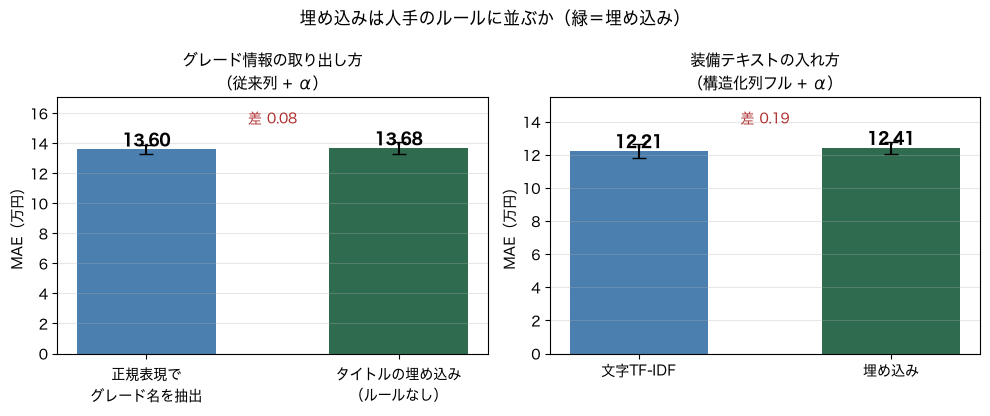

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

pairs = [
    ("グレード情報の取り出し方\n（従来列 + α）",
     [("正規表現で\nグレード名を抽出", BASE["Ab1 +グレード名（正規表現）"], 0.284, "#4a7fb0"),
      ("タイトルの埋め込み\n（ルールなし）",
       results["D2 従来列+タイトル埋め込み(グレード名なし)"]["MAE"],
       results["D2 従来列+タイトル埋め込み(グレード名なし)"]["MAE_std"], "#2e6b4f")]),
    ("装備テキストの入れ方\n（構造化列フル + α）",
     [("文字TF-IDF", BASE["C2 文字TF-IDF（前回の最良）"], 0.417, "#4a7fb0"),
      ("埋め込み", results["D1 B+装備テキスト埋め込み"]["MAE"],
       results["D1 B+装備テキスト埋め込み"]["MAE_std"], "#2e6b4f")]),
]

for ax, (title, items) in zip(axes, pairs):
    labels = [i[0] for i in items]
    vals = [i[1] for i in items]
    errs = [i[2] for i in items]
    bars = ax.bar(labels, vals, yerr=errs, capsize=5,
                  color=[i[3] for i in items], width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.25, f"{v:.2f}",
                ha="center", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=11); ax.set_ylabel("MAE（万円）")
    ax.set_ylim(0, max(vals) * 1.25); ax.grid(axis="y", alpha=0.3)
    ax.annotate(f"差 {abs(vals[0]-vals[1]):.2f}", xy=(0.5, max(vals) * 1.12),
                ha="center", fontsize=10, color="#b03030")

fig.suptitle("埋め込みは人手のルールに並ぶか（緑＝埋め込み）", fontsize=12)
plt.tight_layout(); plt.show()

---

## 7. 数字ではなく、目で見て確かめる

MAE は「全体としてどれだけ当たったか」しか教えてくれない。
**埋め込みが何を「近い」と見なしているのか**は、実際に引いてみないと分からない。

`unfold` の 03「近い正解例を探す」に相当する動きを再現する。
ランダムに選んだ車について、タイトル埋め込みで最も近い3台を表示する。
**正規表現も検索クエリも使わない、ベクトルの距離だけの検索。**

In [11]:
show_neighbours(df, n_show=3, k=3)


タイトル埋め込みで最も近い車を引く（正規表現を一切使わない検索）

■ 基準: ファンベース G      165.0万円  6年  73,000km
   シエンタ 1.5 ファンベース G ナビ・バックカメラ・Bluetooth
   └ 類似0.986  ファンベース G      160.8万円  シエンタ 1.5 ファンベース G ナビ/バックカメラ
   └ 類似0.975  X             159.5万円  シエンタ 1.5 X ナビ・バックカメラ・Bluetooth
   └ 類似0.969  G             105.0万円  シエンタ 1.5 G ナビ/バックカメラ

■ 基準: Z             325.9万円  1年  7km
   シエンタ ハイブリッド 1.5 Z ETC　ディスプレイオーディオ　全方位カメラ　ブラインドスポットモニター　レーンキープアシス
   └ 類似0.987  G             295.9万円  シエンタ ハイブリッド 1.5 G ETC　ディスプレイオーディオ　全方位カメラ　ブライ
   └ 類似0.977  Z             295.2万円  シエンタ ハイブリッド 1.5 Z 純正ディスプレイオーディオ　全方位カメラ　ブラインド
   └ 類似0.970  Z             289.0万円  シエンタ ハイブリッド 1.5 Z ディスプレイオーディオ・全方位モニター・ETC・ブラ

■ 基準: G             130.1万円  9年  89,000km
   シエンタ ハイブリッド 1.5 G /沖縄県/ガリバーuruma店
   └ 類似0.965  G             156.2万円  シエンタ ハイブリッド 1.5 G /埼玉県/ガリバー新狭山店
   └ 類似0.964  G             264.6万円  シエンタ ハイブリッド 1.5 G /静岡県/ガリバー藤枝南新屋店
   └ 類似0.961  G             176.0万円  シエンタ ハイブリッド 1.5 G /山梨県/ガリバー富士吉田店


### 読み方

**1つ目・2つ目の例はうまくいっている。**
「ファンベース G」の車には「ファンベース G」が、
「ハイブリッド Z」の車には同じ装備構成の車が引かれている。
グレードも装備も表記ゆれを越えて捉えられている。

**3つ目の例が問題を示している。**

```
■ 基準: G  130.1万円  9年  89,000km
   シエンタ ハイブリッド 1.5 G /沖縄県/ガリバーuruma店
   └ 類似0.965  G  156.2万円  … /埼玉県/ガリバー新狭山店
   └ 類似0.964  G  264.6万円  … /静岡県/ガリバー藤枝南新屋店
   └ 類似0.961  G  176.0万円  … /山梨県/ガリバー富士吉田店
```

類似度0.96以上で引かれた3台の価格が **156 / 265 / 176万円とばらばら**。
基準の130万円とも合っていない。

原因はタイトルの書式にある。この店（ガリバー）は**装備を書かず店舗名だけを書く**形式なので、
埋め込みは「`/都道府県/ガリバー◯◯店` という書式が同じ」ことに反応している。
**年式も走行距離も文字列に現れないので、価格を決める情報がほとんど入っていない。**

---

## 8. わかったこと

### 1. 埋め込みは、人手で書いた正規表現と同等の情報を取り出せた

D2（13.68）と Ab1（13.60）が誤差の範囲で一致した。
**`unfold` 機能A の中核的な前提が、実データで裏付けられた。**

### 2. ただし、既存のベースラインは超えられない

最良は依然 C2 の 12.21。全部乗せ（D3 = 12.38）でも届かない。
**シエンタ単一車種では正規表現が完璧に機能してしまうので、置き換える動機がない。**

価値が出るのは正規表現が破綻する場面 — つまり**複数車種への拡張時**。
メーカーごとに表記の作法がバラバラで（トヨタの G / Z、ホンダの EX / L、
輸入車の xDrive20d M Sport …）、人間がパターンを書ききれなくなる。
そこで初めて「機械が自動で取り出せる」ことが利益になる。

**02 のノートブックで出した「複数車種に広げるべき」という結論が、
今回さらに強く裏付けられた。** 埋め込みが正規表現に並べることは確認できたので、
あとは正規表現が使えない場面を用意すればよい。

### 3. 「意味が近い」と「価格が近い」は違う — 機能B への指摘

仕様書の機能B（`LLMPredictor`）は `examples="semantic"` で
「似た事例」を LLM に証拠として渡す設計になっている。

しかし §7 で見たとおり、**埋め込みの「似ている」は価格の近さを意味しない。**
店舗の書式が同じだけで類似度0.96が出てしまい、そのまま近傍として選ぶと
価格が2倍違う車を「根拠」として LLM に渡すことになる。

§1 で見た「同じグレードでも違うグレードでも類似度がほぼ同じ（0.91前後）」が、
その原因を説明している。**コサイン類似度は文章全体の向きしか見ないので、
価格を左右する少数の語（グレード1文字）が長い装備の羅列に埋もれる。**
D2 が成功したのは LightGBM が384次元を個別に扱えたからで、
**同じ埋め込みでも近傍検索に使うと同じようには機能しない。**

考えられる対策：

- 数値列（年式・走行距離）を含めた距離にする
- 価格帯で絞り込んでから、意味的に近い順に並べる
- 埋め込みの入力からノイズ（店舗名・都道府県）を除いてから作る

**どれを採るかは設計判断なので、ミーティングで確認したい点。**

---

## 9. 次にやること

- **データを複数車種に広げる**（最優先。上記2の理由）
- APIキーを入手して、機能A の 05（LLM フォールバック）と機能B を試す
- 埋め込みの入力から店舗名を除いた版を作って、§7 の問題が消えるか確かめる